In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy.stats import bootstrap

np.set_printoptions(legacy='1.25')

# Ejercicio: Intervalos de confianza para datos de biblioteca

Una biblioteca en la Universidad de Florida quiso estimar varias características de los libros en una de las colecciones especiales de la universidad. Entre las preguntas de interes fueron: ¿qué tan antiguo es un libro típico en la colección? y ¿cuánto ha pasado desde que un libro típico ha sido consultado? Ella sospechó que las distribuciones de estas variables son fuertemente sesgadas a la derecha, así que escogió la mediana para describir el centro. En el archivo *biblio.csv* se tienen observaciones de $P=$ nro. de años desde publicación y $C=$ nro. de años desde que fue consultado el libro, para una muestra aleatoria simple de 54 libros de la colección.

* Construye un boxplot de los valores de P y comenta que observas.

In [27]:
data = pd.read_csv('biblio.csv')
data.head()

,C,P
0,1,3
1,9,9
2,4,4
3,1,18
4,1,5


In [28]:
data.describe()

,C,P
count,53.000000,53.000000
mean,9.603774,21.981132
std,15.362717,25.793179
min,0.000000,3.000000
25%,1.000000,9.000000
50%,4.000000,17.000000
75%,10.000000,19.000000
max,72.000000,140.000000


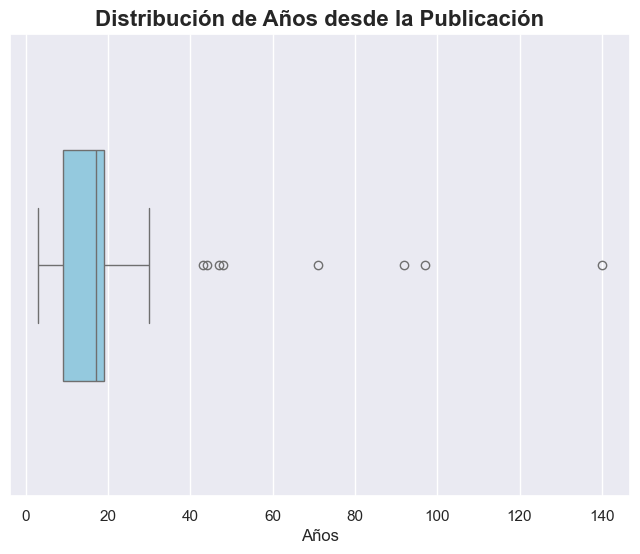

In [29]:
sns.set_theme()
plt.figure(figsize=(8, 6))
sns.boxplot(x='P', data=data, color='skyblue', width=0.5)
plt.title('Distribución de Años desde la Publicación', fontsize=16, fontweight='bold')
plt.xlabel('Años', fontsize=12)
plt.show()

Se observa que los valores de P están sesgados a la derecha, con una cola larga de valores altos. La mediana es menos de 20 años, pero hay valores que llegan hasta 140 años. 

* Utiliza bootsrap para estimar la desviación estándar de la mediana muestral así como para construir un intervalo de confianza de la media poblacional.

Desviación estándar de la mediana para P: 2.2579
IC 95% de la mediana de P: ConfidenceInterval(low=11.0, high=19.0)


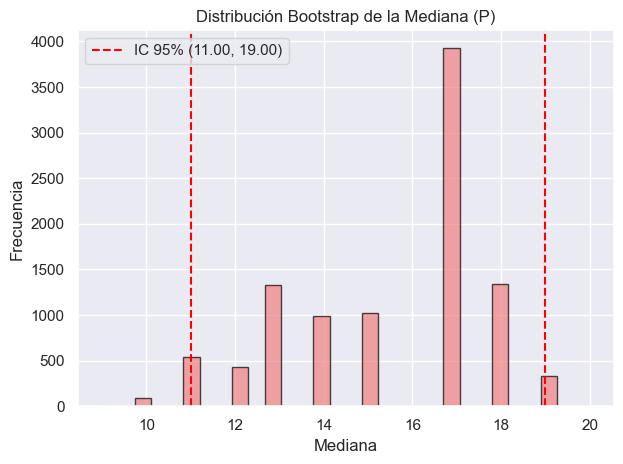

In [30]:
P = data['P'].values
C = data['C'].values
B = 10000

ci_median_P = bootstrap(data=(P,), statistic=np.median, confidence_level=0.95, n_resamples=B, method='percentile')
std_median_P = np.std(ci_median_P.bootstrap_distribution, ddof=1)

print(f"Desviación estándar de la mediana para P: {std_median_P:.4f}")
print(f"IC 95% de la mediana de P: {ci_median_P.confidence_interval}")

plt.hist(ci_median_P.bootstrap_distribution, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(ci_median_P.confidence_interval.low, color='red', linestyle='dashed', label=f'IC 95% ({ci_median_P.confidence_interval.low:.2f}, {ci_median_P.confidence_interval.high:.2f})')
plt.axvline(ci_median_P.confidence_interval.high, color='red', linestyle='dashed')
plt.title('Distribución Bootstrap de la Mediana (P)')
plt.xlabel('Mediana')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

* Construye un intervalo de confianza para la desviación estándar $\sigma$ poblacional del nro. de años desde la publicación de los libros.

Desviación estándar de la mediana para P: 2.2579
IC 95% de la mediana de P: ConfidenceInterval(low=11.0, high=19.0)
IC 95% de la desviación estándar de P: ConfidenceInterval(low=13.112481122929598, high=35.76913507727013)


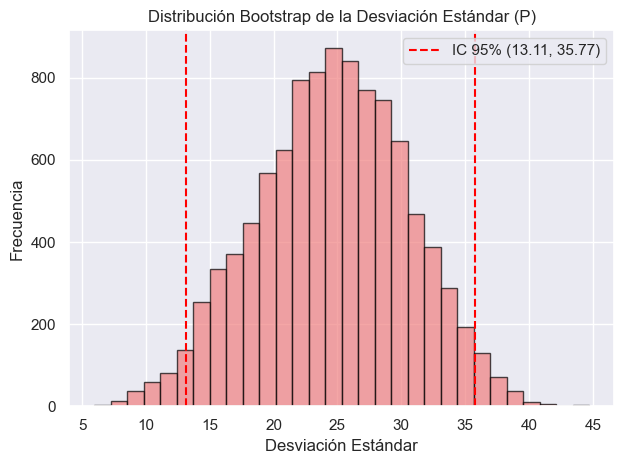

In [31]:
ci_std_P = bootstrap(data=(P,), statistic=np.std, confidence_level=0.95, n_resamples=B, method='percentile')

print(f"Desviación estándar de la mediana para P: {std_median_P:.4f}")
print(f"IC 95% de la mediana de P: {ci_median_P.confidence_interval}")
print(f"IC 95% de la desviación estándar de P: {ci_std_P.confidence_interval}")

plt.hist(ci_std_P.bootstrap_distribution, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(ci_std_P.confidence_interval.low, color='red', linestyle='dashed', label=f'IC 95% ({ci_std_P.confidence_interval.low:.2f}, {ci_std_P.confidence_interval.high:.2f})')
plt.axvline(ci_std_P.confidence_interval.high, color='red', linestyle='dashed')
plt.title('Distribución Bootstrap de la Desviación Estándar (P)')
plt.xlabel('Desviación Estándar')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()

* Finalmente utiliza bootstrap para crear un histograma de la distribución de la correlación muestral entre P y C.

Desviación estándar de la mediana para C: 0.8883
Desviación estándar de la mediana para P: 2.2579
IC 95% de la mediana de C: ConfidenceInterval(low=2.0, high=7.0)
IC 95% de la mediana de P: ConfidenceInterval(low=11.0, high=19.0)
IC 95% de la desviación estándar de P: ConfidenceInterval(low=13.112481122929598, high=35.76913507727013)
IC 95% de la desviación estándar de C: ConfidenceInterval(low=7.934507349806255, high=20.61574311247679)
IC 95% de la correlación entre P y C: ConfidenceInterval(low=-0.19345601768367904, high=0.3282985978769193)


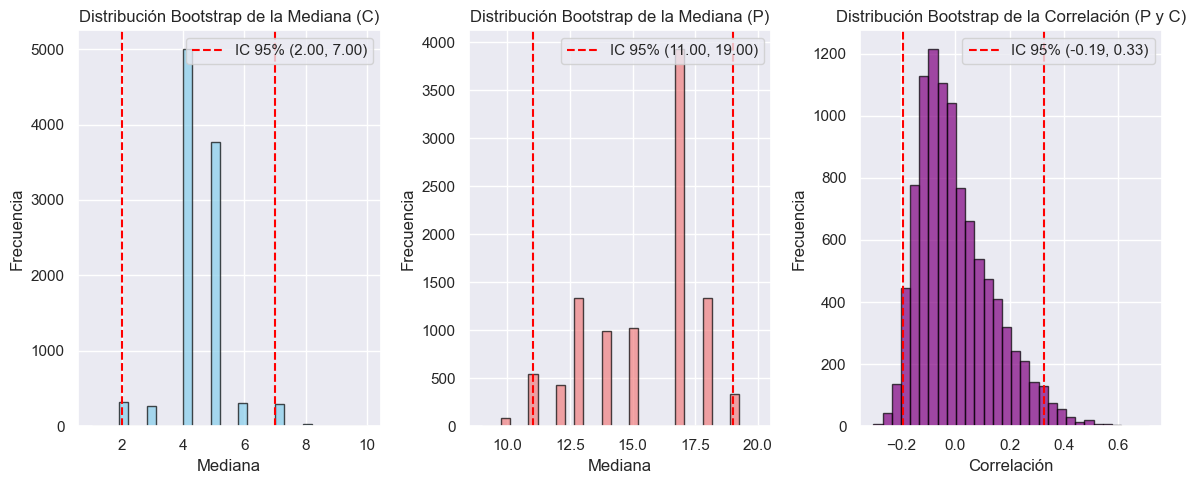

In [32]:
def corr_stat(p, c):
    return np.corrcoef(p, c)[0, 1]

ci_median_C = bootstrap(data=(C,), statistic=np.median, confidence_level=0.95, n_resamples=B, method='percentile')
std_median_C = np.std(ci_median_C.bootstrap_distribution, ddof=1)
ci_std_C = bootstrap(data=(C,), statistic=np.std, confidence_level=0.95, n_resamples=B, method='percentile')

ci_corr = bootstrap(data=(P, C), statistic=corr_stat, confidence_level=0.95, n_resamples=B, method='percentile')

print(f"Desviación estándar de la mediana para C: {std_median_C:.4f}")
print(f"Desviación estándar de la mediana para P: {std_median_P:.4f}")
print(f"IC 95% de la mediana de C: {ci_median_C.confidence_interval}")
print(f"IC 95% de la mediana de P: {ci_median_P.confidence_interval}")
print(f"IC 95% de la desviación estándar de P: {ci_std_P.confidence_interval}")
print(f"IC 95% de la desviación estándar de C: {ci_std_C.confidence_interval}")
print(f"IC 95% de la correlación entre P y C: {ci_corr.confidence_interval}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 3, 1)
plt.hist(ci_median_C.bootstrap_distribution, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(ci_median_C.confidence_interval.low, color='red', linestyle='dashed', label=f'IC 95% ({ci_median_C.confidence_interval.low:.2f}, {ci_median_C.confidence_interval.high:.2f})')
plt.axvline(ci_median_C.confidence_interval.high, color='red', linestyle='dashed')
plt.title('Distribución Bootstrap de la Mediana (C)')
plt.xlabel('Mediana')
plt.ylabel('Frecuencia')
plt.legend()

plt.subplot(1, 3, 2)
plt.hist(ci_median_P.bootstrap_distribution, bins=30, color='lightcoral', edgecolor='black', alpha=0.7)
plt.axvline(ci_median_P.confidence_interval.low, color='red', linestyle='dashed', label=f'IC 95% ({ci_median_P.confidence_interval.low:.2f}, {ci_median_P.confidence_interval.high:.2f})')
plt.axvline(ci_median_P.confidence_interval.high, color='red', linestyle='dashed')
plt.title('Distribución Bootstrap de la Mediana (P)')
plt.xlabel('Mediana')
plt.ylabel('Frecuencia')
plt.legend()

plt.subplot(1, 3, 3)
plt.hist(ci_corr.bootstrap_distribution, bins=30, color='purple', edgecolor='black', alpha=0.7)
plt.axvline(ci_corr.confidence_interval.low, color='red', linestyle='dashed', label=f'IC 95% ({ci_corr.confidence_interval.low:.2f}, {ci_corr.confidence_interval.high:.2f})')
plt.axvline(ci_corr.confidence_interval.high, color='red', linestyle='dashed')
plt.title('Distribución Bootstrap de la Correlación (P y C)')
plt.xlabel('Correlación')
plt.ylabel('Frecuencia')
plt.legend()

plt.tight_layout()
plt.show()